## Mecánica del vuelo - Tarea N°2: Velocidad y aerodinámica
### Datos simulados

#### Actividad 1

In [8]:
with open('cessna172_actividad1.csv', 'r') as archivo:
    lineas = [line.rstrip(';') for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
altitude = []    # [ft]

for i in lineas[1:-1]:
    v_indicated.append(float(i.split(';')[0]))
    v_true.append(float(i.split(';')[2]))
    altitude.append(float(i.split(';')[9]))

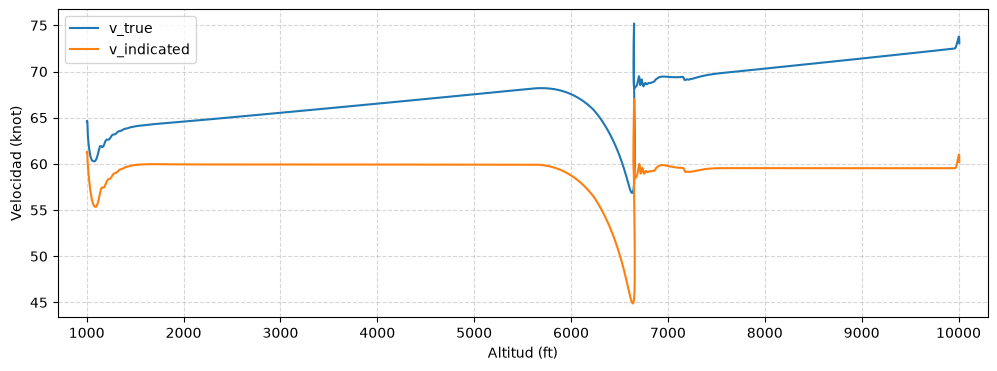

In [31]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12,4)

plt.plot(altitude[66:], v_true[66:], label='v_true')
plt.plot(altitude[66:], v_indicated[66:], label='v_indicated')
plt.xticks(range(0, 10001, 1000))
plt.xlim(700, 10300)
plt.xlabel('Altitud (ft)')
plt.ylabel('Velocidad (knot)')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#### Actividad 2

In [4]:
with open('cessna172-100kn-1000ft.csv', 'r') as archivo:
    lineas = [line.rstrip() for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
altitude = []    # [km]
lift = []        # [N]
drag = []        # [N]
alpha = []       # [°]

for i in lineas[1:-1]:
    v_indicated.append(float(i.split(',')[0]))
    v_true.append(float(i.split(',')[2]))
    lift.append(float(i.split(',')[20])*4.45)
    drag.append(float(i.split(',')[26])*4.45)
    altitude.append(float(i.split(',')[14]) * 0.3048 / 1000)
    alpha.append(float(i.split(',')[7]))

In [2]:
def cL(sust, altura):
    c_L = []
    if altura==1000: rho = 1.18955 # kg/m3
    else:            rho = 0.90464 # kg/m3
    for i in range(len(sust)):
        c_L.append(2 * sust[i] / (rho * 188*(0.3048**2) * (v_true[i]*0.514)**2))
    return c_L

def cD(arr, altura):
    c_D = []
    if altura==1000: rho = 1.18955 # kg/m3
    else:            rho = 0.90464 # kg/m3
    for i in range(len(arr)):
        c_D.append(2 * arr[i] / (rho * 188*(0.3048**2) * (v_true[i]*0.514)**2))
    return c_D

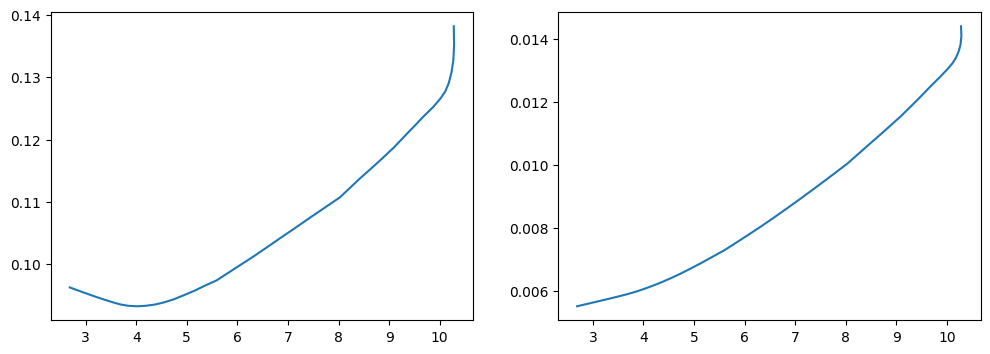

In [5]:
import matplotlib.pyplot as plt
from numpy import pi

plt.rcParams['figure.figsize'] = (12,4)
fig, (ax1, ax2) = plt.subplots(1,2)

ax1.plot(alpha[28:-12], cL(lift[28:-12], 1000))

ax2.plot(alpha[28:-12], cD(drag[28:-12], 1000))

Text(0, 0.5, 'Ángulo de ataque [°]')

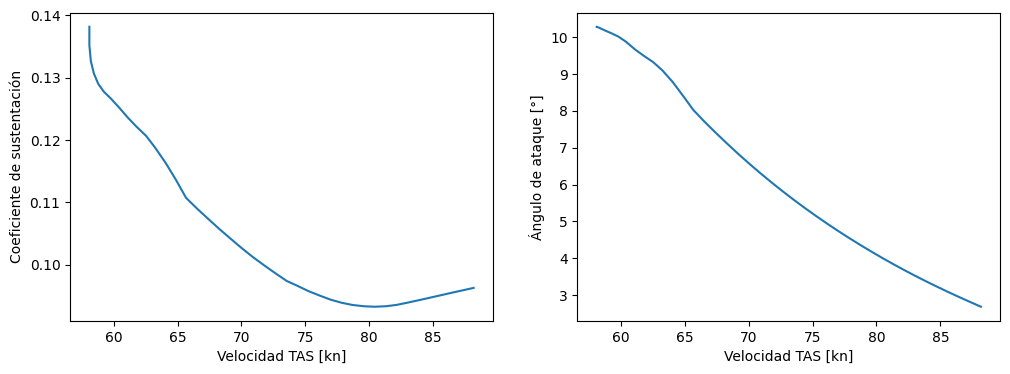

In [6]:
plt.rcParams['figure.figsize'] = (12,4)
fig, (ax1, ax2) = plt.subplots(1,2)

ax1.plot(v_true[28:-12], cL(lift[28:-12], 1000))
ax1.set_xlabel('Velocidad TAS [kn]')
ax1.set_ylabel('Coeficiente de sustentación')

ax2.plot(v_true[28:-12], alpha[28:-12])
ax2.set_xlabel('Velocidad TAS [kn]')
ax2.set_ylabel('Ángulo de ataque [°]')